# Stock Price Movement Prediction — ML Pipeline

This notebook builds a complete machine learning pipeline to predict the
daily direction (up/down) of a stock's closing price.

**Primary Goal:** Classify whether tomorrow's return will be positive (1) or negative (0).

**Pipeline Overview:**
Data → EDA → Feature Engineering → Model Selection → Evaluation → Backtesting → Strategy Metrics

In [ ]:
# Step 1: Import libraries
import pandas as pd

# Step 2: Create example price data
data = {
    "price": [100, 102, 101, 103, 104, 102]
}

df1 = pd.DataFrame(data)

# Step 3: Create daily returns
df1["return"] = df1["price"].pct_change()

# Step 4: Create future return (label source)
df1["future_return"] = df1["return"].shift(-1)

# Step 5: Drop rows with missing values
# (first row: no return, last row: no future return)
df1 = df1.dropna()

# Step 6: Create target (1 = up, 0 = down)
df1["target"] = (df1["future_return"] > 0).astype(int)

# Step 7: Final result
print(df1)


   price    return  future_return  target
1    102  0.020000      -0.009804       0
2    101 -0.009804       0.019802       1
3    103  0.019802       0.009709       1
4    104  0.009709      -0.019231       0


###USER CONFIG

In [ ]:
TICKER     = "AAPL"
START_DATE = "2020-01-01"
END_DATE   = "2025-01-01"
SPLIT_DATE = "2023-01-01"

###Imprting Necessary libraries

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

print(f"Running analysis for: {TICKER}  ({START_DATE} → {END_DATE})")

Running analysis for: AAPL  (2020-01-01 → 2025-01-01)


### Data Loading
####Data Pipeline

- yfinance provides free, reliable OHLCV (Open, High, Low, Close, Volume) data
directly from Yahoo Finance.

- OHLCV is a standard way of summarizing trading data for a financial asset (like a stock, crypto, or commodity) over a given time interval

In [ ]:
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

if df.empty:
    raise ValueError(f"No data found for ticker '{TICKER}'.")

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel('Ticker')



[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200
...,...,...,...,...,...
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700
2024-12-26,257.612762,258.686912,256.230330,256.787285,27237100
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300


In [ ]:
df.describe()

Price,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.517254,153.040436,149.818776,151.362795,9.057103e+07
std,41.890558,42.031052,41.667657,41.834312,5.324438e+07
min,54.213608,55.211524,51.372088,55.110042,2.323470e+07
25%,126.395451,127.514450,124.393008,125.840228,5.546825e+07
50%,150.106773,151.849537,148.173558,149.926893,7.628335e+07
75%,176.064091,177.615918,174.497867,175.870113,1.077425e+08
max,257.612762,258.686912,256.230330,256.787285,4.265100e+08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
 1   High    1258 non-null   float64
 2   Low     1258 non-null   float64
 3   Open    1258 non-null   float64
 4   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


- (Close, AAPL) → The closing price of Apple stock each day.
- (High, AAPL) → The highest price reached during that trading day.
- (Low, AAPL) → The lowest price reached during that trading day.
- (Open, AAPL) → The opening price at the start of the trading day.
- (Volume, AAPL) → The number of shares traded that day.


##Exploratory Data Analysis (EDA)

why are we doing EDA?


Raw prices are non-stationary (they trend). ML models assume statistical
properties of input data are stable over time. Daily returns (pct_change)
are approximately stationary and are therefore used instead of raw prices.

In [ ]:
#Compute daily returns
df["return"] = df["Close"].pct_change()

In [ ]:
df

Price,Close,High,Low,Open,Volume,return
Date,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800,-0.009722
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200,0.007968
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000,-0.004703
2020-01-08,73.085098,73.386416,71.631544,71.631544,132079200,0.016086
...,...,...,...,...,...,...
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700,0.011478
2024-12-26,257.612762,258.686912,256.230330,256.787285,27237100,0.003176
2024-12-27,254.201370,257.294489,251.685117,256.429191,42355300,-0.013242


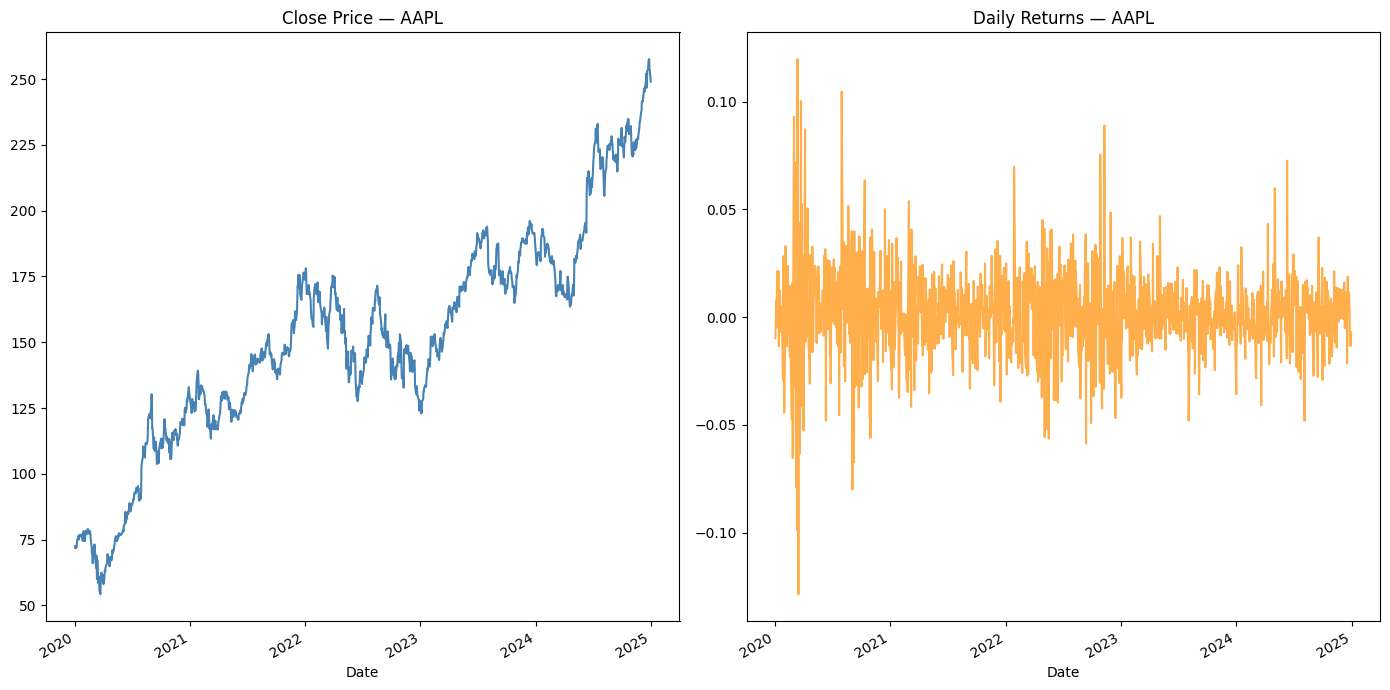

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
df["Close"].plot(ax=axes[0], title=f"Close Price — {TICKER}", color="steelblue")
df["return"].plot(ax=axes[1], title=f"Daily Returns — {TICKER}", color="darkorange", alpha=0.7)
plt.tight_layout()
plt.show()

### Return Distribution — Checking for Fat Tails

Financial returns are known to have **leptokurtosis** (fat tails) — meaning
extreme events occur more frequently than a normal distribution would predict.
This has implications for risk modeling and why simple linear models can fail.

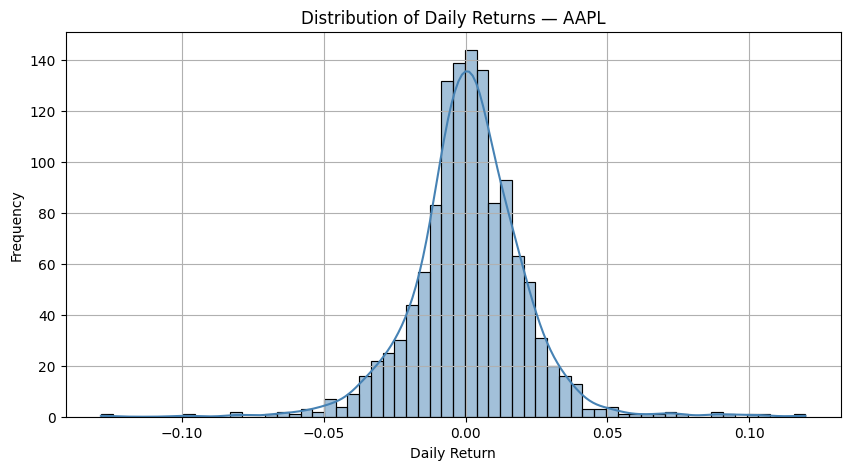

Skewness : 0.1056   (0 = symmetric)
Kurtosis : 5.2778   (3 = normal, >3 = fat tails)


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["return"].dropna(), bins=60, kde=True, color="steelblue")
plt.title(f"Distribution of Daily Returns — {TICKER}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Skewness and Kurtosis
print(f"Skewness : {df['return'].skew():.4f}   (0 = symmetric)")
print(f"Kurtosis : {df['return'].kurt():.4f}   (3 = normal, >3 = fat tails)")

### Statistical Hypothesis Test

1. P-value (Statistical Hypothesis Testing)
- What it is: A p-value measures how likely your observed data would occur if the null hypothesis were true.
- Intuition: Imagine you flip a coin 100 times and get 70 heads. If the coin were fair, that outcome is pretty unlikely. The p-value quantifies that “unlikeliness.”


- If p_val < 0.05, you reject the null → Apple’s returns are not just random noise, there’s a statistically significant drift.
- If p_val > 0.05, you can’t reject the null → returns look like noise around zero.


 Important: A p-value does not tell you the probability the hypothesis is true. It’s about the probability of the data given the hypothesis.


In [ ]:
t_stat, p_val = stats.ttest_1samp(df["return"].dropna(), 0)
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}")

if p_val < 0.05:
    print("→ Statistically significant drift detected. Prediction may be feasible.")
else:
    print("→ No significant drift. Returns resemble random noise.")

t-statistic : 2.1002
p-value     : 0.0359
→ Statistically significant drift detected. Prediction may be feasible.


### Autocorrelation Function (ACF)

If past returns have significant autocorrelation with future returns,
lagged features will be informative for the model.

Most liquid stocks show very weak autocorrelation (Efficient Market Hypothesis),
but short-term momentum and mean-reversion patterns can exist.

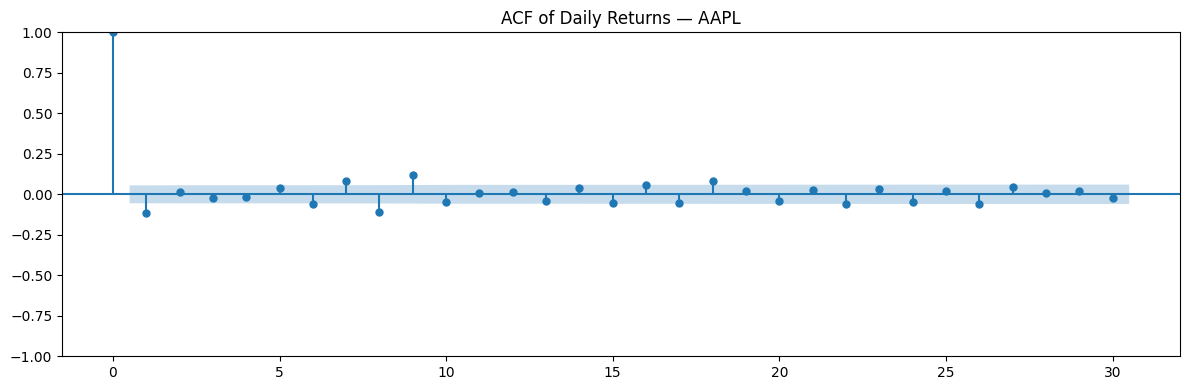

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df["return"].dropna(), lags=30, ax=ax)
ax.set_title(f"ACF of Daily Returns — {TICKER}")
plt.tight_layout()
plt.show()

###Target Creation

`target = 1` if tomorrow's return > 0, else `target = 0`

In [ ]:
df["future_return"] = df["return"].shift(-1)
df = df.dropna()
df["target"] = (df["future_return"] > 0).astype(int)

In [ ]:
print(df['target'].value_counts())
print(df["target"].mean())
print(f"\nClass balance: {df['target'].mean():.2%} positive days")

target
1    670
0    586
Name: count, dtype: int64
0.5334394904458599

Class balance: 53.34% positive days


###Baseline Model

In [ ]:
df["baseline_pred"] = (df["return"] > 0).astype(int)
baseline_acc = (df["baseline_pred"] == df["target"]).mean()
print(f"Naive baseline accuracy: {baseline_acc:.4f}")

Naive baseline accuracy: 0.4889


## Feature Engineering (Alpha Engine)

Feature engineering is the most impactful step in the pipeline.
We construct features from 4 categories:

| Category | Feature | Financial Intuition |
|---|---|---|
| Trend | SMA ratio | Captures whether price is above/below its average |
| Momentum | 10-day momentum | Trend continuation signal |
| Volatility | Rolling std dev | High volatility = uncertainty, regime signal |
| Volume | Volume pct change | Unusual volume often precedes price moves |
| Lagged returns | ret_lag_1 to 5 | Short-term mean reversion / momentum |
| RSI | Relative Strength | Overbought/oversold conditions |

**Why not use raw OHLC prices as features?**
Raw prices are non-stationary and contain scale that the model
would memorize rather than generalize from. All features are
derived as ratios, differences, or normalized quantities.

**Why rolling windows of 5 and 10?**
- 5-day ≈ 1 trading week (short-term noise)
- 10-day ≈ 2 trading weeks (medium-term trend)
These are standard windows in quantitative finance literature.

In [ ]:
def create_features(df):
    df = df.copy()

    # --- TREND ---
    # SMA ratio: is price above its short/long average?
    df["sma_5"]       = df["Close"].rolling(5).mean()
    df["sma_10"]      = df["Close"].rolling(10).mean()
    df["sma_20"]      = df["Close"].rolling(20).mean()
    df["sma_ratio"]   = df["sma_5"] / df["sma_20"]  # >1 = uptrend

    # --- MOMENTUM ---
    # Price 10 days ago vs today
    df["momentum_10"] = df["Close"] / df["Close"].shift(10) - 1

    # --- VOLATILITY ---
    df["ret_std_5"]   = df["return"].rolling(5).std()
    df["ret_std_10"]  = df["return"].rolling(10).std()
    df["ret_mean_5"]  = df["return"].rolling(5).mean()
    df["ret_mean_10"] = df["return"].rolling(10).mean()

    # --- VOLUME ---
    df["volume_change"] = df["Volume"].pct_change()
    df["volume_ma_ratio"] = df["Volume"] / df["Volume"].rolling(10).mean()

    # --- RSI (14-day) ---
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # --- LAGGED RETURNS ---
    for lag in range(1, 6):
        df[f"ret_lag_{lag}"] = df["return"].shift(lag)

    return df

df = create_features(df)
df = df.dropna()

print(f"Total features created: {len([c for c in df.columns if c not in ['Open','High','Low','Close','Volume','return','target','future_return','baseline_pred']])}")
df.head()

Total features created: 17


Price,Close,High,Low,Open,Volume,return,future_return,target,baseline_pred,sma_5,...,ret_mean_5,ret_mean_10,volume_change,volume_ma_ratio,rsi_14,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-31,74.608566,77.783241,74.314480,77.361397,199588400,-0.044339,-0.002746,0,0,76.383206,...,-0.005194,-0.001617,0.574746,1.359375,49.368852,-0.001449,0.020932,0.028290,-0.029405,-0.002882
2020-02-03,74.403671,75.567958,72.851284,73.352673,173788400,-0.002746,0.033014,1,0,76.369228,...,0.000138,-0.002999,-0.129266,1.155348,42.987544,-0.044339,-0.001449,0.020932,0.028290,-0.029405
2020-02-04,76.860016,77.050450,75.601715,76.006683,136616400,0.033014,0.008154,1,1,76.425153,...,0.001082,0.000980,-0.213892,0.892928,54.739538,-0.002746,-0.044339,-0.001449,0.020932,0.028290
2020-02-05,77.486740,78.284628,76.884106,77.985716,118826800,0.008154,0.011697,1,1,76.285822,...,-0.001473,0.001438,-0.130216,0.768123,57.618605,0.033014,-0.002746,-0.044339,-0.001449,0.020932
2020-02-06,78.393120,78.395533,77.199908,77.756741,105425600,0.011697,-0.013593,0,1,76.350423,...,0.001156,0.002127,-0.112779,0.681075,57.529079,0.008154,0.033014,-0.002746,-0.044339,-0.001449


### Time-Series Train/Test Split

In [ ]:
features = [
    "sma_ratio", "momentum_10",
    "ret_mean_5", "ret_std_5",
    "ret_mean_10", "ret_std_10",
    "volume_change", "volume_ma_ratio",
    "rsi_14",
    "ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"
]

In [ ]:
train = df[df.index <= SPLIT_DATE]
test  = df[df.index > SPLIT_DATE]

X_train, y_train = train[features], train["target"]
X_test,  y_test  = test[features],  test["target"]

### Model Selection & Training

In [ ]:
# --- Model 1: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_probs):.4f}")

=== Logistic Regression ===
Accuracy : 0.5429
ROC-AUC  : 0.4947


In [ ]:
# --- Model 2: XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_probs):.4f}")

=== XGBoost ===
Accuracy : 0.5190
ROC-AUC  : 0.5110


In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary",   # equivalent to logloss
    verbosity=-1          # suppress output
)

lgbm_model.fit(X_train, y_train)
lgb_preds = lgbm_model.predict(X_test)
lgb_probs = lgbm_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"Accuracy : {accuracy_score(y_test, lgb_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lgb_probs):.4f}")

=== LightGBM ===
Accuracy : 0.5230
ROC-AUC  : 0.5260


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

# Collect results in a structured list
results_data = [
    {
        "Model": "Naive Baseline",
        "Accuracy": baseline_acc,
        "ROC-AUC": 0.5
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_preds),
        "ROC-AUC": roc_auc_score(y_test, lr_probs)
    },
    {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, xgb_preds),
        "ROC-AUC": roc_auc_score(y_test, xgb_probs)
    },

    {
    "Model": "LightGBM",
    "Accuracy": accuracy_score(y_test, lgb_preds),
    "ROC-AUC": roc_auc_score(y_test, lgb_probs)
    }
]

# Convert to DataFrame
results = pd.DataFrame(results_data)

# Display neatly
print("=== Model Comparison ===")
print(results.to_string(index=False))


=== Model Comparison ===
              Model  Accuracy  ROC-AUC
     Naive Baseline  0.488854 0.500000
Logistic Regression  0.542914 0.494721
            XGBoost  0.518962 0.510962
           LightGBM  0.522954 0.525956


In [ ]:
import subprocess
subprocess.run(["pip", "install", "optuna", "lightgbm", "--quiet"],
               capture_output=True)

CompletedProcess(args=['pip', 'install', 'optuna', 'lightgbm', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv = TimeSeriesSplit(n_splits=5)

def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"       : trial.suggest_int("max_depth", 2, 6),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma"           : trial.suggest_float("gamma", 0, 0.5),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.5, 2.0),
        "random_state"    : 42,
        "eval_metric"     : "logloss",
        "verbosity"       : 0
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring="roc_auc")
    return scores.mean()

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost AUC (CV): {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost AUC (CV): 0.5039
Best params: {'n_estimators': 237, 'max_depth': 6, 'learning_rate': 0.06630538609864825, 'subsample': 0.8234484061389961, 'colsample_bytree': 0.9805742460745419, 'min_child_weight': 9, 'gamma': 0.1835436681464952, 'reg_alpha': 0.6523107569705949, 'reg_lambda': 1.071562242614638}


In [ ]:
import lightgbm as lgb

def lgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"       : trial.suggest_int("max_depth", 2, 6),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves"      : trial.suggest_int("num_leaves", 10, 60),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.5, 2.0),
        "random_state"    : 42,
        "verbose"         : -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring="roc_auc")
    return scores.mean()

lgb_study = optuna.create_study(direction="maximize")
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM AUC (CV): {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM AUC (CV): 0.5181
Best params: {'n_estimators': 141, 'max_depth': 5, 'learning_rate': 0.044366888484367026, 'num_leaves': 35, 'subsample': 0.7545060603878645, 'colsample_bytree': 0.9957800348764851, 'min_child_samples': 20, 'reg_alpha': 0.15128961156855447, 'reg_lambda': 1.1864833596264739}
